# Домашняя работа 3. Pandas и визуальный анализ данных

Датасет — пассажиры Titanic (`titanic.csv`). В работе: преобразование столбцов, строковые методы Pandas, фильтрация и визуальный анализ категориальных и числовых признаков. Пропуски специально не заполняются и не удаляются; `groupby`, `merge` и Plotly не используются.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Задание 1. Загрузка и понимание данных

Загружаем датасет в `df` и смотрим на размер, столбцы, типы данных, пропуски и основные статистики.

In [2]:
df = pd.read_csv("titanic.csv")

print("Строк и столбцов:", df.shape)
df.head()

Строк и столбцов: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print("Количество пропусков по столбцам:")
print(df.isna().sum())

Количество пропусков по столбцам:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Первичный анализ.** В таблице 891 пассажир и 12 столбцов. Пропуски есть в трёх столбцах: `Age` (177, около 20% строк), `Cabin` (687, почти 80%) и `Embarked` (2). Выжили около 38% пассажиров (среднее `Survived` ≈ 0.38). Стоимость билета `Fare` сильно различается: медиана около 14, а максимум больше 512.

**Категориальные признаки:**
- `Survived` — выжил (1) или нет (0); хранится числом, но по смыслу это категория;
- `Pclass` — класс билета 1, 2, 3; тоже число, но это упорядоченная категория (порядковый признак);
- `Sex` — пол;
- `Embarked` — порт посадки (C, Q, S);
- `Name`, `Ticket`, `Cabin` — текстовые признаки, почти уникальные для каждого пассажира: это скорее идентификаторы, чем категории для анализа.

**Числовые признаки:**
- `Age` — возраст (непрерывный);
- `Fare` — стоимость билета (непрерывный);
- `SibSp` — число братьев, сестёр и супругов на борту (дискретный);
- `Parch` — число родителей и детей на борту (дискретный).

`PassengerId` — числовой идентификатор строки, для анализа он не используется.

## Задание 2. Преобразования столбцов

### 2.1. Размер семьи

`family_size = SibSp + Parch + 1`

In [6]:
df["family_size"] = df["SibSp"] + df["Parch"] + 1

df[["SibSp", "Parch", "family_size"]].head()

,SibSp,Parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


**Почему прибавляется 1?** `SibSp` и `Parch` считают только родственников пассажира, но не его самого. Чтобы получить размер всей семьи на борту, нужно добавить самого пассажира. Поэтому у человека, путешествовавшего в одиночку, `family_size = 0 + 0 + 1 = 1`, а не 0.

### 2.2. Стоимость билета на одного члена семьи

Делим стоимость билета на размер семьи. Деления на ноль не будет: `family_size` всегда не меньше 1.

In [7]:
df["fare_per_person"] = df["Fare"] / df["family_size"]

df[["Fare", "family_size", "fare_per_person"]].head()

,Fare,family_size,fare_per_person
0,7.2500,2,3.62500
1,71.2833,2,35.64165
2,7.9250,1,7.92500
3,53.1000,2,26.55000
4,8.0500,1,8.05000


### 2.3. Работа со строковыми данными

- `name_length` — длина имени через `.str.len()`;
- `has_mrs` — содержит ли имя `"Mrs."`.

В `.str.contains()` передаём `regex=False`: по умолчанию строка трактуется как регулярное выражение, а в нём точка означает «любой символ». Тогда `"Mrs."` совпало бы и с `"Mrs"`, за которым идёт пробел или другой символ, и подсчёт был бы неточным.

In [8]:
df["name_length"] = df["Name"].str.len()
df["has_mrs"] = df["Name"].str.contains("Mrs.", regex=False)

df[["Name", "name_length", "has_mrs"]].head()

,Name,name_length,has_mrs
0,"Braund, Mr. Owen Harris",23,False
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",51,True
2,"Heikkinen, Miss. Laina",22,False
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",44,True
4,"Allen, Mr. William Henry",24,False


In [9]:
mrs_count = df["has_mrs"].sum()
print("Количество строк, где has_mrs == True:", mrs_count)

# Для сравнения: сколько совпадений даёт поиск с regex=True, где точка — «любой символ»
mrs_count_regex = df["Name"].str.contains("Mrs.", regex=True).sum()
print("Совпадений при regex=True:", mrs_count_regex)

Количество строк, где has_mrs == True: 125
Совпадений при regex=True: 129


С `regex=True` находится на 4 строки больше. Это пассажирки с обращением `Miss.`, `Mlle.` или `Lady.`, у которых в скобках указано второе имя вида `"Mrs Harbeck"` — без точки после `Mrs`. Обращения `Mrs.` у них нет, поэтому правильный ответ — 125, с `regex=False`.

## Задание 3. Фильтрация

Каждую группу сохраняем в отдельный DataFrame и выводим количество строк.

### 3.1. Женщины первого класса

In [10]:
first_class_women = df[(df["Sex"] == "female") & (df["Pclass"] == 1)]
print("Женщин первого класса:", len(first_class_women))

Женщин первого класса: 94


### 3.2. Возраст не меньше 18 и стоимость билета больше 50

Пассажиры без указанного возраста (`NaN`) в выборку не попадают: сравнение `NaN >= 18` даёт `False`.

In [11]:
adults_expensive = df[(df["Age"] >= 18) & (df["Fare"] > 50)]
print("Взрослых пассажиров с билетом дороже 50:", len(adults_expensive))

Взрослых пассажиров с билетом дороже 50: 127


### 3.3. Выжившие с размером семьи больше 3

In [12]:
survived_big_family = df[(df["Survived"] == 1) & (df["family_size"] > 3)]
print("Выживших с размером семьи больше 3:", len(survived_big_family))

Выживших с размером семьи больше 3: 31


### 3.4. `"Mrs."` в имени и стоимость билета больше 30

Используем уже созданный логический столбец `has_mrs`.

In [13]:
mrs_expensive = df[df["has_mrs"] & (df["Fare"] > 30)]
print("Пассажирок с 'Mrs.' в имени и билетом дороже 30:", len(mrs_expensive))

Пассажирок с 'Mrs.' в имени и билетом дороже 30: 50


## Задание 4. Визуальный анализ

### 4.1. Распределение пассажиров по классам

`Pclass` — категориальный признак с тремя значениями, поэтому подходит столбчатая диаграмма с количеством пассажиров в каждом классе.

In [14]:
class_counts = df["Pclass"].value_counts().sort_index()
print(class_counts)
print()
print("Доли классов:")
print(df["Pclass"].value_counts(normalize=True).sort_index().round(3))

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Доли классов:
Pclass
1    0.242
2    0.207
3    0.551
Name: proportion, dtype: float64


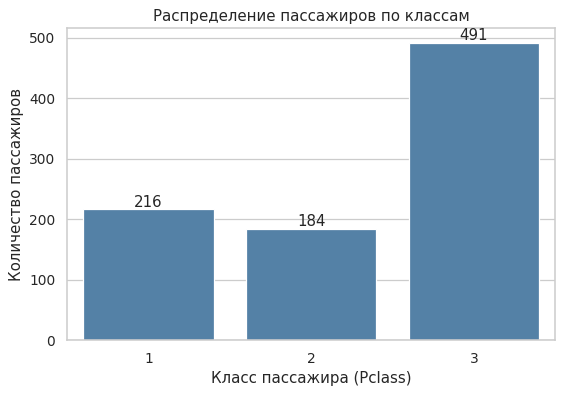

In [15]:
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(data=df, x="Pclass", color="steelblue")
ax.bar_label(ax.containers[0])
plt.title("Распределение пассажиров по классам")
plt.xlabel("Класс пассажира (Pclass)")
plt.ylabel("Количество пассажиров")
plt.show()

**Вывод.** Больше половины пассажиров (491 из 891, около 55%) ехали третьим классом. Первым и вторым классом ехало примерно поровну: 216 и 184 человека. Классы по численности сильно не сбалансированы, и это важно учитывать при сравнении групп.

### 4.2. Распределение возраста

`Age` — непрерывный числовой признак, поэтому строим гистограмму. Пассажиры с пропущенным возрастом (177 человек) на графике не учитываются.

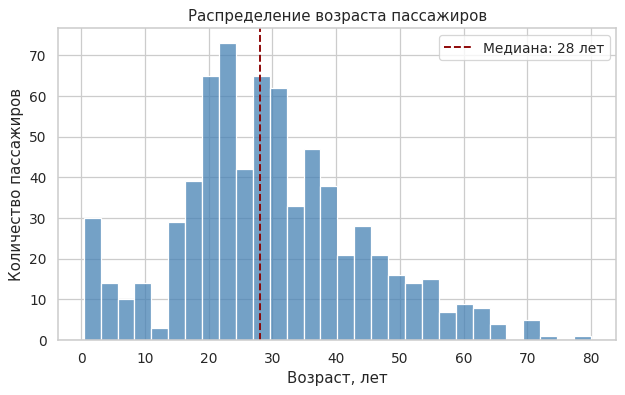

In [16]:
plt.figure(figsize=(8, 4.5))
sns.histplot(data=df, x="Age", bins=30, color="steelblue")
plt.axvline(df["Age"].median(), color="darkred", linestyle="--", label=f"Медиана: {df['Age'].median():.0f} лет")
plt.title("Распределение возраста пассажиров")
plt.xlabel("Возраст, лет")
plt.ylabel("Количество пассажиров")
plt.legend()
plt.show()

**Вывод.** Большинству пассажиров было от 20 до 40 лет, медианный возраст — 28 лет. Отдельно заметна группа маленьких детей до 5 лет, а пожилых пассажиров старше 60 совсем немного (максимум — 80 лет).

### 4.3. Распределение стоимости билета

`Fare` — непрерывный числовой признак с большим разбросом. Используем два графика: гистограмма показывает форму распределения, а boxplot — медиану, разброс и выбросы.

In [17]:
print(df["Fare"].describe().round(2))
print()
print("Билетов дороже 100:", (df["Fare"] > 100).sum())
print("Билетов со стоимостью 0:", (df["Fare"] == 0).sum())

count    891.00
mean      32.20
std       49.69
min        0.00
25%        7.91
50%       14.45
75%       31.00
max      512.33
Name: Fare, dtype: float64

Билетов дороже 100: 53
Билетов со стоимостью 0: 15


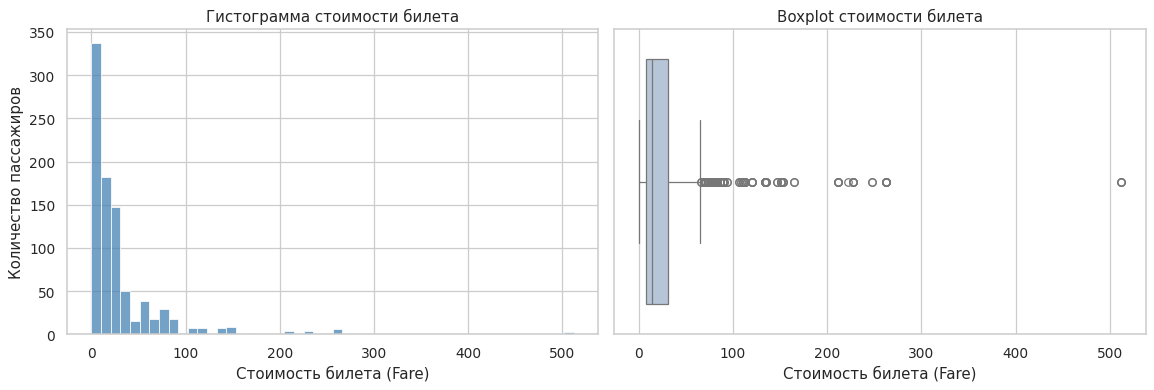

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(data=df, x="Fare", bins=50, color="steelblue", ax=axes[0])
axes[0].set_title("Гистограмма стоимости билета")
axes[0].set_xlabel("Стоимость билета (Fare)")
axes[0].set_ylabel("Количество пассажиров")

sns.boxplot(data=df, x="Fare", color="lightsteelblue", ax=axes[1])
axes[1].set_title("Boxplot стоимости билета")
axes[1].set_xlabel("Стоимость билета (Fare)")

plt.tight_layout()
plt.show()

**Вывод.** Распределение сильно скошено вправо: у половины пассажиров билет стоил меньше 14.5, а у 75% — не больше 31, при этом максимум превышает 512. На boxplot видно много выбросов выше «уса» (дорогие билеты первого класса), а среднее (≈32) из-за них заметно больше медианы. Также есть 15 билетов со стоимостью 0 — возможно, это служебные или бесплатные места.

### 4.4. Стоимость билета по классам

Сравниваем числовой признак (`Fare`) между группами категориального (`Pclass`) — для этого подходит boxplot по группам: сразу видны медианы, разброс и выбросы в каждом классе.

In [19]:
for pclass in sorted(df["Pclass"].unique()):
    median_fare = df.loc[df["Pclass"] == pclass, "Fare"].median()
    print(f"Класс {pclass}: медианная стоимость билета = {median_fare:.2f}")

Класс 1: медианная стоимость билета = 60.29
Класс 2: медианная стоимость билета = 14.25
Класс 3: медианная стоимость билета = 8.05


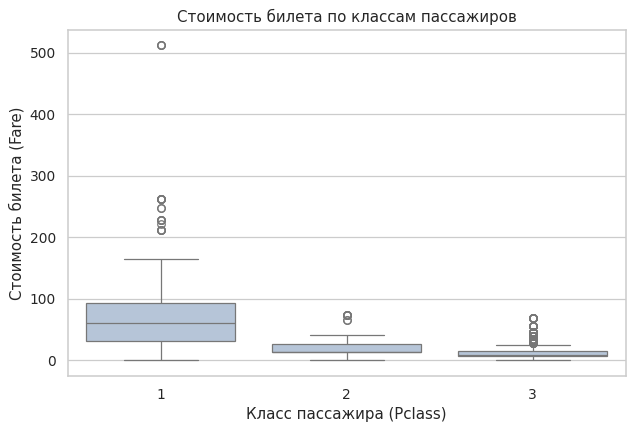

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Pclass", y="Fare", color="lightsteelblue")
plt.title("Стоимость билета по классам пассажиров")
plt.xlabel("Класс пассажира (Pclass)")
plt.ylabel("Стоимость билета (Fare)")
plt.show()

**Вывод.** Стоимость билета резко растёт с классом: медиана в первом классе около 60, во втором — около 14, в третьем — около 8. Разброс цен в первом классе намного больше, и именно там находятся все самые дорогие билеты (до 512), а «ящики» второго и третьего классов целиком лежат ниже «ящика» первого.

### 4.5. Связь возраста и стоимости билета с учётом выживания

Два числовых признака — диаграмма рассеяния; цвет точки показывает, выжил пассажир или нет. Пассажиры без возраста на график не попадают.

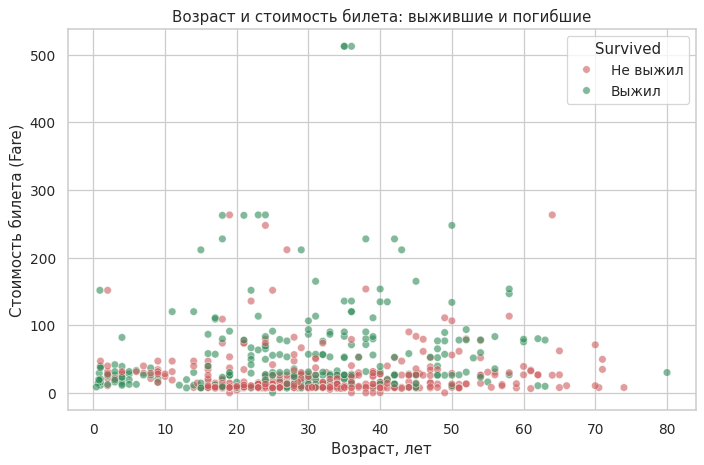

In [21]:
plt.figure(figsize=(9, 5.5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived",
    palette={0: "indianred", 1: "seagreen"},
    alpha=0.6,
)
plt.title("Возраст и стоимость билета: выжившие и погибшие")
plt.xlabel("Возраст, лет")
plt.ylabel("Стоимость билета (Fare)")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Не выжил", "Выжил"], title="Survived")
plt.show()

**Вывод.** Явной линейной связи между возрастом и стоимостью билета нет: в каждом возрасте встречаются и дешёвые, и дорогие билеты. Зато видно, что среди пассажиров с дорогими билетами (выше ~50) заметно больше зелёных точек, то есть выживших, а в плотной массе дешёвых билетов преобладают погибшие. Также среди маленьких детей много выживших.

### 4.6. Связь класса и выживаемости

Оба признака категориальные. Считаем таблицу частот `crosstab` с нормировкой по строкам (доля выживших внутри каждого класса) и строим накопленную столбчатую диаграмму долей.

In [22]:
survival_by_class = pd.crosstab(df["Pclass"], df["Survived"], normalize="index")
survival_by_class.columns = ["Не выжил", "Выжил"]
survival_by_class.round(3)

,Не выжил,Выжил
Pclass,,
1,0.370,0.630
2,0.527,0.473
3,0.758,0.242


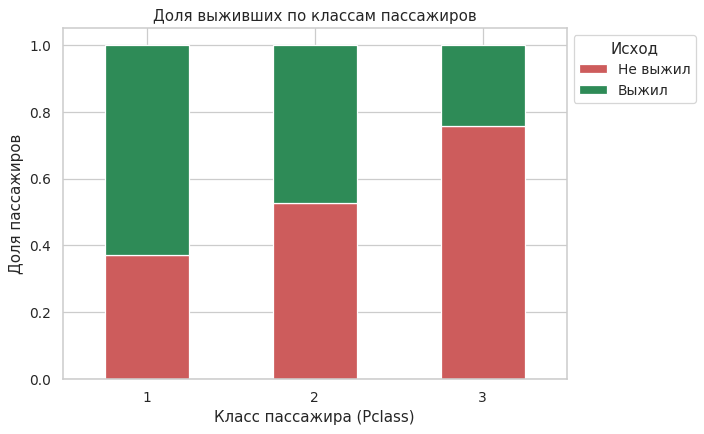

In [23]:
ax = survival_by_class.plot(
    kind="bar",
    stacked=True,
    color=["indianred", "seagreen"],
    figsize=(8, 5),
)
plt.title("Доля выживших по классам пассажиров")
plt.xlabel("Класс пассажира (Pclass)")
plt.ylabel("Доля пассажиров")
plt.xticks(rotation=0)
plt.legend(title="Исход", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

**Вывод.** Выживаемость сильно зависит от класса: в первом классе выжили около 63% пассажиров, во втором — около 47%, в третьем — только около 24%. Учитывая, что третьим классом ехало больше половины пассажиров, основная часть погибших пришлась именно на него.

### 4.7. Собственный вопрос: как выживаемость связана с размером семьи?

**Почему такой график:** `family_size` — дискретный признак с небольшим числом значений, поэтому удобно показать столбец для каждого размера семьи и разделить его цветом на выживших и погибших — так одновременно видно и сколько людей было в каждой группе, и как в ней соотносятся исходы.

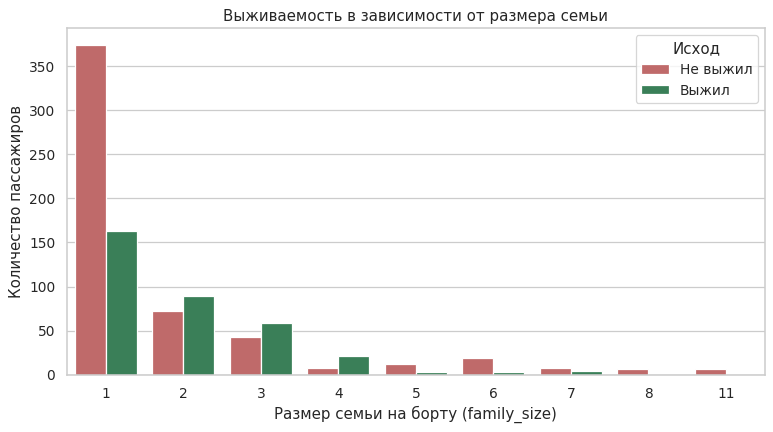

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="family_size",
    hue="Survived",
    palette={0: "indianred", 1: "seagreen"},
)
plt.title("Выживаемость в зависимости от размера семьи")
plt.xlabel("Размер семьи на борту (family_size)")
plt.ylabel("Количество пассажиров")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Не выжил", "Выжил"], title="Исход")
plt.show()

In [25]:
print("Доля выживших по размеру семьи:")
print(pd.crosstab(df["family_size"], df["Survived"], normalize="index")[1].round(2))

Доля выживших по размеру семьи:
family_size
1     0.30
2     0.55
3     0.58
4     0.72
5     0.20
6     0.14
7     0.33
8     0.00
11    0.00
Name: 1, dtype: float64


**Вывод.** Одиночки — самая большая группа (537 человек), и выжили из них лишь около 30%. У пассажиров с семьёй из 2–4 человек выживаемость заметно выше (55–72%), а в больших семьях от 5 человек снова падает: в семьях из 8 и 11 человек не выжил никто. При этом больших семей мало, поэтому выводы по ним менее надёжны.

### 4.8. Корреляции

Считаем корреляции Пирсона для пяти числовых признаков и визуализируем их тепловой картой.

In [26]:
corr_columns = ["Age", "Fare", "SibSp", "Parch", "family_size"]
corr_matrix = df[corr_columns].corr()
corr_matrix.round(2)

,Age,Fare,SibSp,Parch,family_size
Age,1.00,0.10,-0.31,-0.19,-0.30
Fare,0.10,1.00,0.16,0.22,0.22
SibSp,-0.31,0.16,1.00,0.41,0.89
Parch,-0.19,0.22,0.41,1.00,0.78
family_size,-0.30,0.22,0.89,0.78,1.00


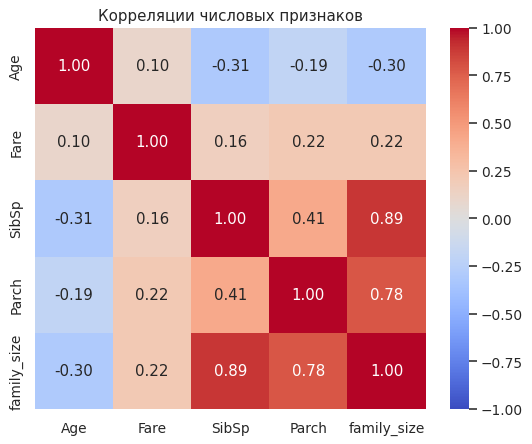

In [27]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляции числовых признаков")
plt.show()

**Вывод.** Самая заметная положительная связь — между `SibSp` и `family_size` (0.89), затем `Parch` и `family_size` (0.78). Но она ожидаема: `family_size` вычислен из этих столбцов. Среди исходных признаков наиболее заметная положительная связь — между `SibSp` и `Parch` (0.41): люди, путешествующие с супругом или братьями и сёстрами, часто едут и с детьми или родителями. Возраст слабо отрицательно связан с числом родственников на борту (−0.31 с `SibSp`): с большими семьями ехало много детей.

## Задание 5. Итоговый вывод

**1. Наиболее заметные наблюдения.**
- Выживаемость сильно зависит от класса: около 63% в первом классе против 24% в третьем, при этом третьим классом ехало больше половины пассажиров.
- Стоимость билета распределена очень неравномерно: медиана около 14.5, но есть билеты дороже 500, и почти все дорогие билеты — в первом классе.
- Пассажиры с небольшой семьёй (2–4 человека) выживали чаще, чем одиночки и члены больших семей.

**2. Самая полезная визуализация.**
Накопленная диаграмма долей выживших по классам (4.6): она сразу показывает главный вывод — чем выше класс, тем больше шансов выжить, и сравнивает доли, а не абсолютные числа, поэтому неравный размер классов не мешает сравнению.

**3. Чем отличаются два способа анализа одной числовой переменной?**
Для `Fare` использованы гистограмма и boxplot. Гистограмма показывает форму распределения: где сосредоточено большинство значений и насколько оно скошено. Boxplot сжимает распределение до медианы, квартилей и «усов» и явно выделяет выбросы, зато по нему не видно, например, несколько ли пиков у распределения.

**4. Почему важно понимать тип переменной перед выбором визуализации?**
От типа переменной зависит, какой график вообще имеет смысл. Для категориальных признаков (`Pclass`, `Sex`) нужны подсчёты и доли — столбчатые диаграммы; для числовых (`Age`, `Fare`) — гистограммы и boxplot; для связи двух числовых — диаграмма рассеяния. Например, `Pclass` хранится числом, но строить по нему гистограмму или считать «средний класс» бессмысленно — это категория.